## Notebook changes or specifying
in this notebook i watn to achieve different things:
* understand why i dont get color in my motorcycles (why are they mostly gray)
* attempt to over fit and underfit to see each scenario
* attempt to improve the training set, by: seeing how image size has an effect, centering images based on the wheels, or to improve how centered they might be.
* try different loss algorithms
* understanding in depth what im doing to make adjustments and improve image generation.


In [71]:
import tensorflow as tf
from tensorflow import keras
import math
#from keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Flatten, Dense, Lambda, Reshape

from keras import ops
from keras import layers

from keras import Model, Input
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

sys.path.append(os.path.abspath('..'))
from proyecto1_deep_learning.data_loader import load_data_3



In [72]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6999697763283545316
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3758096384
locality {
  bus_id: 1
  links {
  }
}
incarnation: 12480885567564652257
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1772084858.545934   10671 gpu_device.cc:2020] Created device /device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [73]:
##why the helly does this not work?
x_train, x_test = load_data_3()

image_shape = x_train.shape[1:]
num_channels = image_shape[2]
print(f"Image shape: {image_shape}")

Image shape: (128, 128, 3)


In [74]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

In [75]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


In [76]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

In [77]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


In [ ]:
latent_dim = 28
image_size_x = 128
image_size_y = 128

encoder_inputs = keras.Input(shape=(image_size_x, image_size_y, 3))

x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(512, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

shape_before_flattening = x.shape[1:]

x = layers.Flatten()(x)
x = layers.Dense(128)(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(np.prod(shape_before_flattening))(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Reshape(shape_before_flattening)(x)

x = layers.Conv2DTranspose(512, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

decoder_outputs = layers.Conv2DTranspose(
    3, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │        896 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_40       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     18,496 │ activation_40[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │     73,856 │ activation_41[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ activation_42[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_43       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16384)     │          0 │ activation_43[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 40)        │    655,400 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 28)        │      1,148 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 28)        │      1,148 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_4          │ (None, 28)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 1,048,032 (4.00 MB)

 Trainable params: 1,047,072 (3.99 MB)

 Non-trainable params: 960 (3.75 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16384)          │       475,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_24             │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,520,835 (5.80 MB)

 Trainable params: 1,487,107 (5.67 MB)

 Non-trainable params: 33,728 (131.75 KB)

In [79]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta #adding beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # MSE loss (no automatic reduction)
            reconstruction_loss = ops.mean(
                ops.sum(
                    ops.square(data - reconstruction),
                    axis=(1, 2, 3),
                )
            )

            # KL divergence
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = ops.mean(
            ops.sum(
                ops.square(data - reconstruction),
                axis=(1, 2, 3),
            )
        )

        kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
        kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

        total_loss = reconstruction_loss + (self.beta * kl_loss)

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }
        


In [80]:
motorcycle_brum_brum = np.concatenate([x_train, x_test], axis=0)

beta = 1

vae = VAE(encoder, decoder, beta)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(x_train, epochs=100)




Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - kl_loss: 0.7666 - loss: 9176.4160 - reconstruction_loss: 9175.6484
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - kl_loss: 101.2794 - loss: 5078.0420 - reconstruction_loss: 4976.7627
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - kl_loss: 8.3806 - loss: 2882.6646 - reconstruction_loss: 2874.2839
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - kl_loss: 47.5041 - loss: 2402.1775 - reconstruction_loss: 2354.6733
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - kl_loss: 39.0220 - loss: 2303.2197 - reconstruction_loss: 2264.1978
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - kl_loss: 32.1858 - loss: 2212.0366 - reconstruction_loss: 2179.8506
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - kl_loss: 17.9589 - loss: 2149.7896 - reconstruction_loss: 2131.8311
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - kl_loss: 10.1147 - loss: 2148.8210 - reconstruction_loss: 2138.7065
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


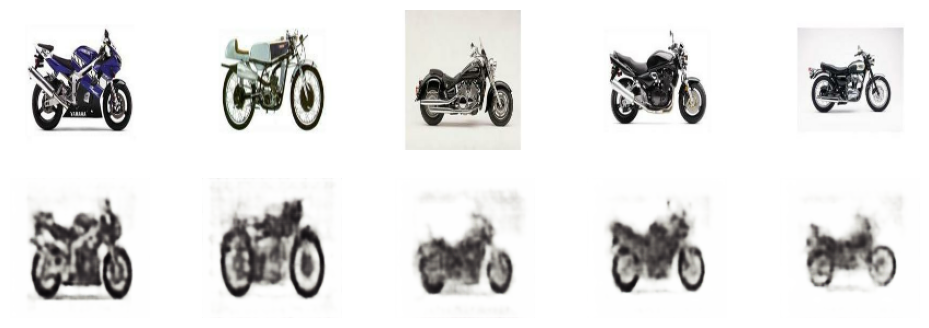

In [81]:
import matplotlib.pyplot as plt
import numpy as np

def show_reconstructions(model, data, n=5):
    z_mean, z_log_var, z = model.encoder.predict(data[:n])
    reconstructions = model.decoder.predict(z)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i])
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i])
        plt.axis("off")

    plt.show()

show_reconstructions(vae, x_test)

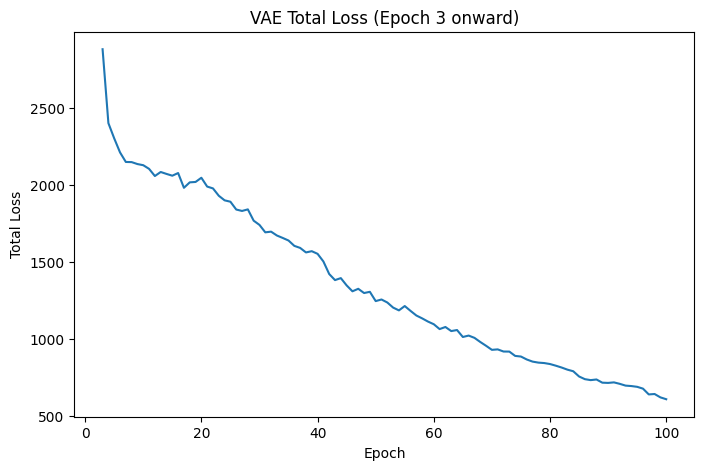

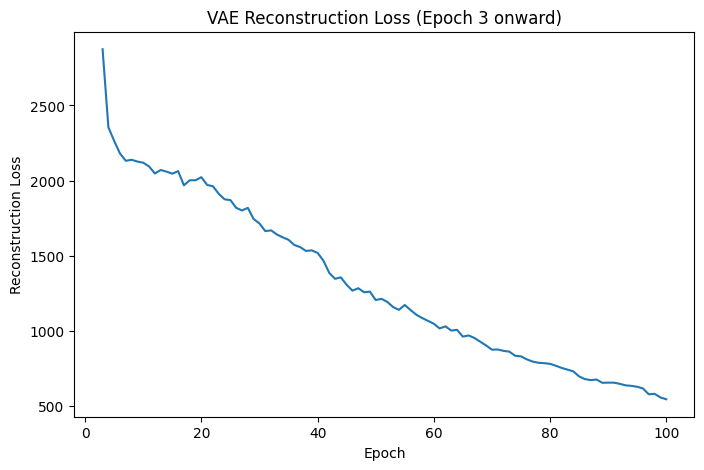

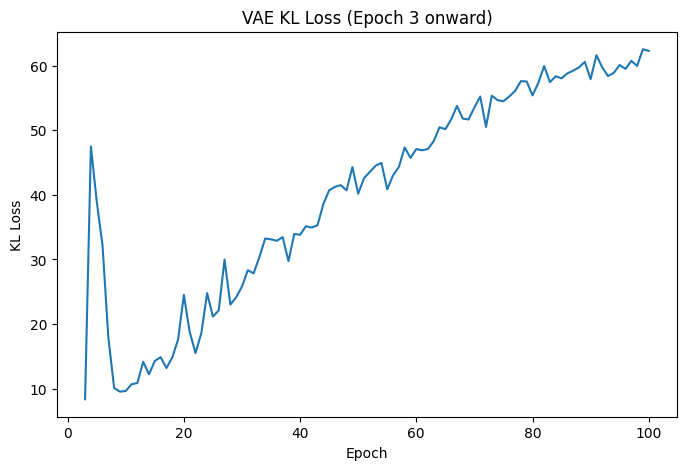

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Ignore first 2 epochs
epochs = np.arange(3, len(history.history["loss"]) + 1)

total_loss = history.history["loss"][2:]
recon_loss = history.history["reconstruction_loss"][2:]
kl_loss = history.history["kl_loss"][2:]

# ---- Total Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, total_loss)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("VAE Total Loss (Epoch 3 onward)")
plt.show()

# ---- Reconstruction Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, recon_loss)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Reconstruction Loss (Epoch 3 onward)")
plt.show()

# ---- KL Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, kl_loss)
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("VAE KL Loss (Epoch 3 onward)")
plt.show()

In [83]:
def evaluate_vae(model, data):
    z_mean, z_log_var, z = model.encoder.predict(data, verbose=0)
    reconstruction = model.decoder.predict(z, verbose=0)

    reconstruction_loss = np.mean(
        np.sum((data - reconstruction) ** 2, axis=(1, 2, 3))
    )

    kl_loss = -0.5 * (1 + z_log_var - z_mean**2 - np.exp(z_log_var))
    kl_loss = np.mean(np.sum(kl_loss, axis=1))

    total_loss = reconstruction_loss + kl_loss

    print("Evaluation Results:")
    print(f"Reconstruction Loss: {reconstruction_loss:.4f}")
    print(f"KL Loss: {kl_loss:.4f}")
    print(f"Total Loss: {total_loss:.4f}")

    return total_loss, reconstruction_loss, kl_loss

In [84]:
evaluate_vae(vae, x_test)

Evaluation Results:
Reconstruction Loss: 1152.1293
KL Loss: 59.4707
Total Loss: 1211.6000


(np.float32(1211.6), np.float32(1152.1293), np.float32(59.47074))

In [85]:
LATENT_DIM = latent_dim

def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    if save_path is None:
        save_path = f"./reports/figures/3.04-smdeo-generated_images_{n_images}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Generated images saved to {save_path}")


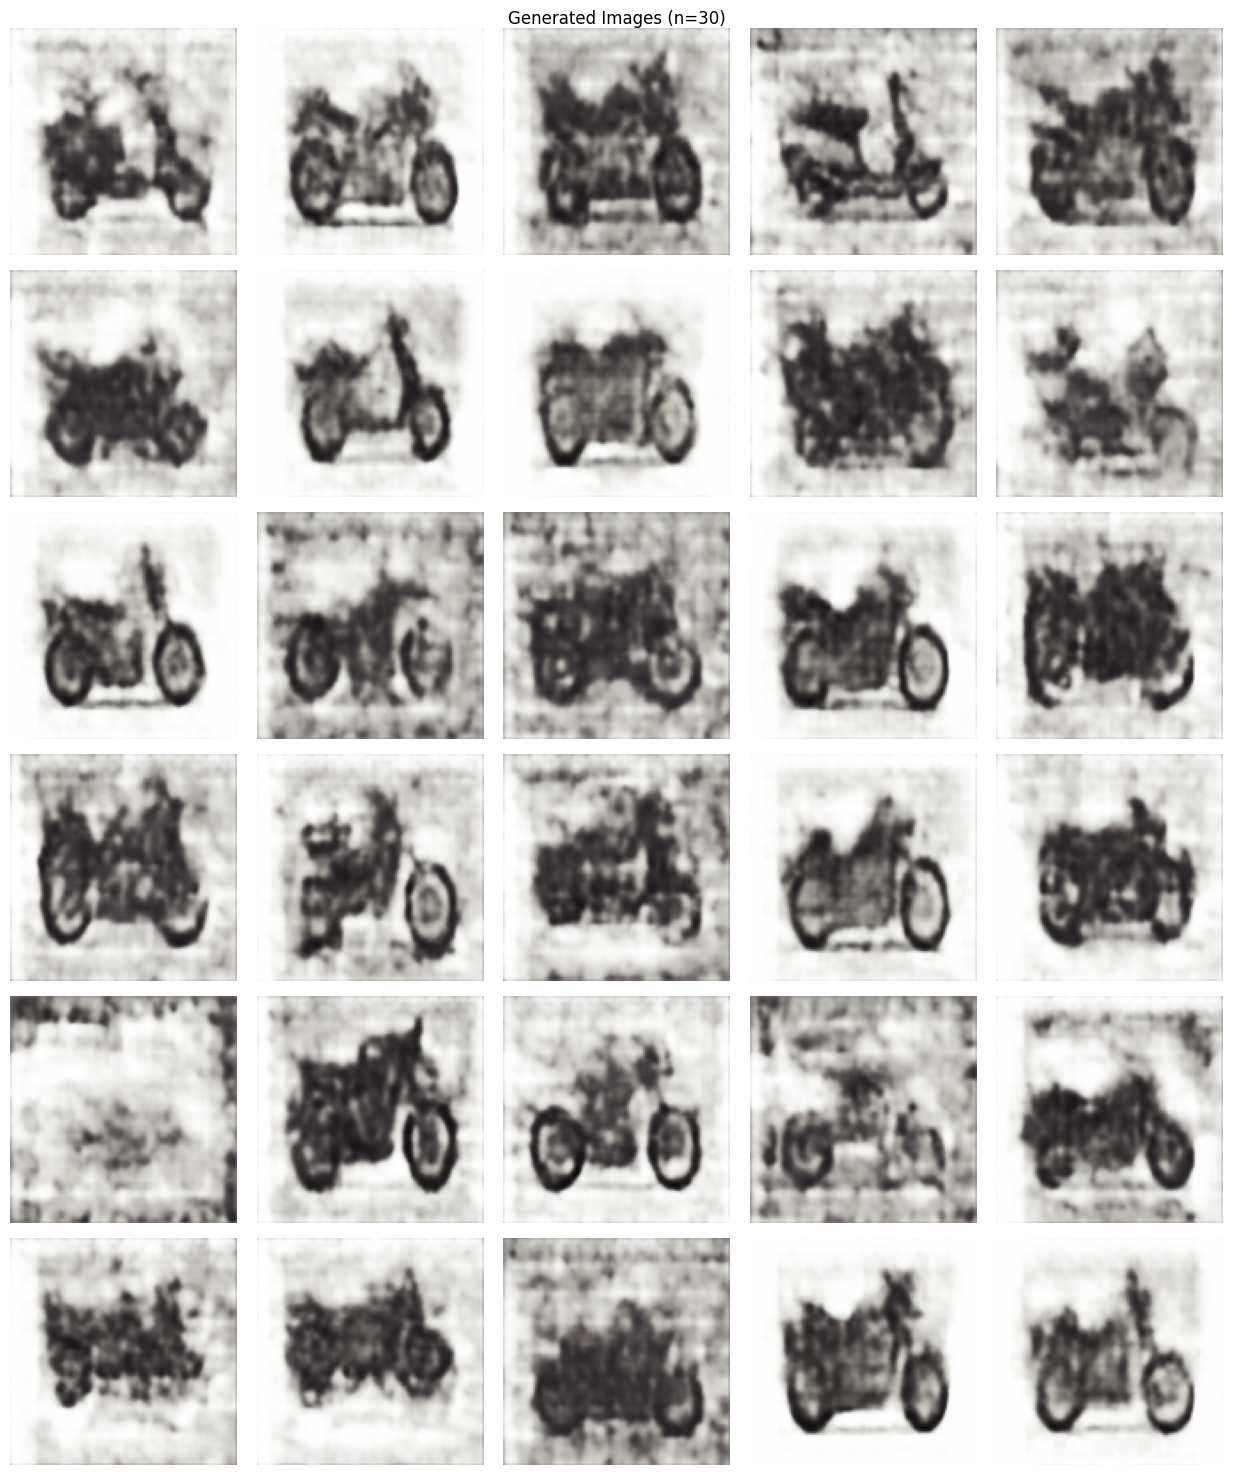

Generated images saved to ./reports/figures/3.04-smdeo-generated_images_30.png


In [86]:
generated_images = generate_images(decoder, n_images=30)
plot_generated_images(generated_images, n_images=30)

In [87]:
# models_path = "./models"

# # ---- Save encoder ----
# encoder.save(os.path.join(models_path, "encoder_smdo_3-05.keras"))

# # ---- Save decoder ----
# decoder.save(os.path.join(models_path, "decoder_smdo_3-05.keras"))

# ---- Save full VAE ----
# vae.save("./models/vae_smdo_3-04.keras", include_optimizer=True)
# vae.save("./models/vae_smdo_3-04.keras")
# vae.save("./models/vae_savedmodel_smdo_3-04", save_format="tf")
# vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

print("Models saved successfully")


# try:
#     models_path = "../models"

#     # ---- Save encoder ----
#     encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

#     # ---- Save decoder ----
#     decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

#     # ---- Save full VAE ----
#     vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

#     print("Models saved successfully")
# except Exception as e:
#     models_path = "./models"

#     # ---- Save encoder ----
#     encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

#     # ---- Save decoder ----
#     decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

#     # ---- Save full VAE ----
#     vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

#     print("Models saved successfully")

Models saved successfully
